# ex09_lti_plus_periodic_rotor

Interactive notebook version of the Python example.
Edit parameters and rerun cells to explore the model behavior.


## MATLAB-style Sections

- PBSIDopt identification of Smart Rotor with periodic effects
- With rotor speed of 370 RPM
- With rotor speed of 430 RPM


## Imports


In [4]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from _common import (
    estimate_varx_abcdk,
    frequency_response,
    simulate_lti,
    stable_random_system,
    state_space_model,
    vaf_percent,
)
from scipy.io import loadmat

## Helper Functions


In [5]:
def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "examples").exists() and (candidate / "python").exists():
            return candidate
    return cwd

def _load_or_synthesize(case: str) -> tuple[np.ndarray, np.ndarray, float, float]:
    repo_root = _find_repo_root()
    mat_path = repo_root / "examples" / f"smartrotor{case}.mat"
    if mat_path.exists():
        m = loadmat(mat_path, squeeze_me=False, struct_as_record=False)
        u = np.asarray(m["u"], dtype=np.float64)
        y = np.asarray(m["y"], dtype=np.float64)
        if u.shape[0] < u.shape[1]:
            u = u.T
        if y.shape[0] < y.shape[1]:
            y = y.T
        rpm = float(case)
        return u, y, 0.01, rpm

    rpm = float(case)
    ts = 0.01
    a, b, c, d, k = stable_random_system(n=12, r=2, l_out=2, seed=200 + int(case))
    n_samples = 6000
    rng = np.random.default_rng(200 + int(case))
    u = np.column_stack((rng.standard_normal(n_samples), rng.standard_normal(n_samples)))
    t = np.arange(n_samples, dtype=np.float64) * ts
    periodic = np.column_stack(
        (
            np.sin(2.0 * np.pi * rpm * t / 60.0),
            np.cos(2.0 * np.pi * rpm * t / 60.0),
        )
    )
    y, _ = simulate_lti(a, b, c, d, u, k=k, e=0.03 * rng.standard_normal((n_samples, 2)))
    y = y + 0.08 * periodic @ np.array([[1.0, 0.5], [-0.3, 0.9]], dtype=np.float64)
    return u, y, ts, rpm

def run_case(case: str) -> dict[str, object]:
    u, y, ts, rpm = _load_or_synthesize(case)
    t = np.arange(u.shape[0], dtype=np.float64) * ts

    harm = np.column_stack(
        (
            np.sin(2.0 * np.pi * rpm * t / 60.0),
            np.cos(2.0 * np.pi * rpm * t / 60.0),
            np.sin(4.0 * np.pi * rpm * t / 60.0),
            np.cos(4.0 * np.pi * rpm * t / 60.0),
        )
    )
    u_aug = np.hstack((u, harm))

    n = 12
    f = 20
    p = 20
    w = np.logspace(0.4, np.log10(1.0 / (2.0 * ts)), 2000) * 2.0 * np.pi

    _, a_plain, b_plain, c_plain, d_plain, _, _, _ = estimate_varx_abcdk(u, y, n, f, p)
    _, a_aug, b_aug, c_aug, d_aug, _, _, _ = estimate_varx_abcdk(u_aug, y, n, f, p)

    y_plain, _ = simulate_lti(a_plain, b_plain, c_plain, d_plain, u)
    y_aug, _ = simulate_lti(a_aug, b_aug, c_aug, d_aug, u_aug)

    plain_sys = state_space_model(a_plain, b_plain, c_plain, d_plain, ts)
    aug_sys = state_space_model(a_aug, b_aug[:, : u.shape[1]], c_aug, d_aug[:, : u.shape[1]], ts)
    response_plain = np.abs(frequency_response(plain_sys, w))
    response_aug = np.abs(frequency_response(aug_sys, w))

    print(f"\n[ex09-RPM-{int(rpm)}]")
    print(f"VAF plain (%): {np.array2string(vaf_percent(y, y_plain), precision=2)}")
    print(f"VAF periodic-aug (%): {np.array2string(vaf_percent(y, y_aug), precision=2)}")

    return {
        "rpm": rpm,
        "ts": ts,
        "w": w,
        "response_plain": response_plain,
        "response_aug": response_aug,
    }

## With Rotor Speed Of 370 RPM
Run the periodic-augmented Smart Rotor identification workflow for the 370 RPM case.

In [6]:
case_370 = run_case("370")


[ex09-RPM-370]
VAF plain (%): [95.93 91.18]
VAF periodic-aug (%): [98.39 95.55]


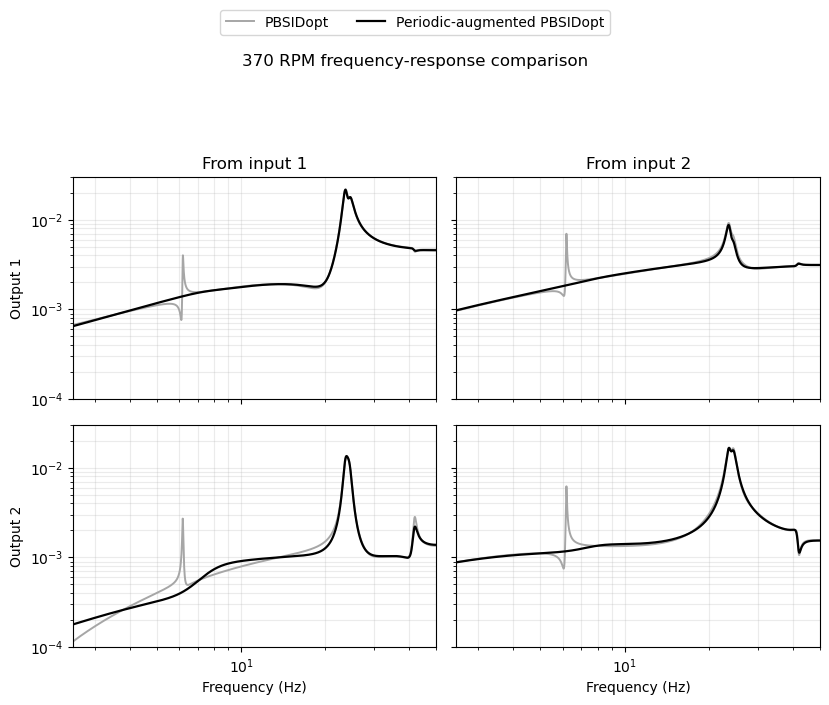

In [11]:
plain = case_370["response_plain"]
aug = case_370["response_aug"]
w = case_370["w"]
freq_hz = w / (2.0 * np.pi)
n_outputs, n_inputs, _ = plain.shape
fig, axes = plt.subplots(
    n_outputs,
    n_inputs,
    figsize=(4.2 * n_inputs, 3.4 * n_outputs),
    squeeze=False,
    sharex=True,
    sharey=True,
)
for row in range(n_outputs):
    for col in range(n_inputs):
        axis = axes[row, col]
        axis.loglog(freq_hz, plain[row, col, :], color="0.65", linewidth=1.4, label="PBSIDopt")
        axis.loglog(
            freq_hz,
            aug[row, col, :],
            color="k",
            linewidth=1.6,
            label="Periodic-augmented PBSIDopt",
        )
        axis.set_xlim(2.5, 50.0)
        axis.set_ylim(1e-4, 3e-2)
        axis.grid(True, which="both", alpha=0.25)
        if row == 0:
            axis.set_title(f"From input {col + 1}")
        if col == 0:
            axis.set_ylabel(f"Output {row + 1}")
        if row == n_outputs - 1:
            axis.set_xlabel("Frequency (Hz)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("370 RPM frequency-response comparison", y=0.965)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.88))

## With Rotor Speed Of 430 RPM
Run the periodic-augmented Smart Rotor identification workflow for the 430 RPM case.

In [8]:
case_430 = run_case("430")


[ex09-RPM-430]
VAF plain (%): [97.29 94.54]
VAF periodic-aug (%): [97.47 95.59]


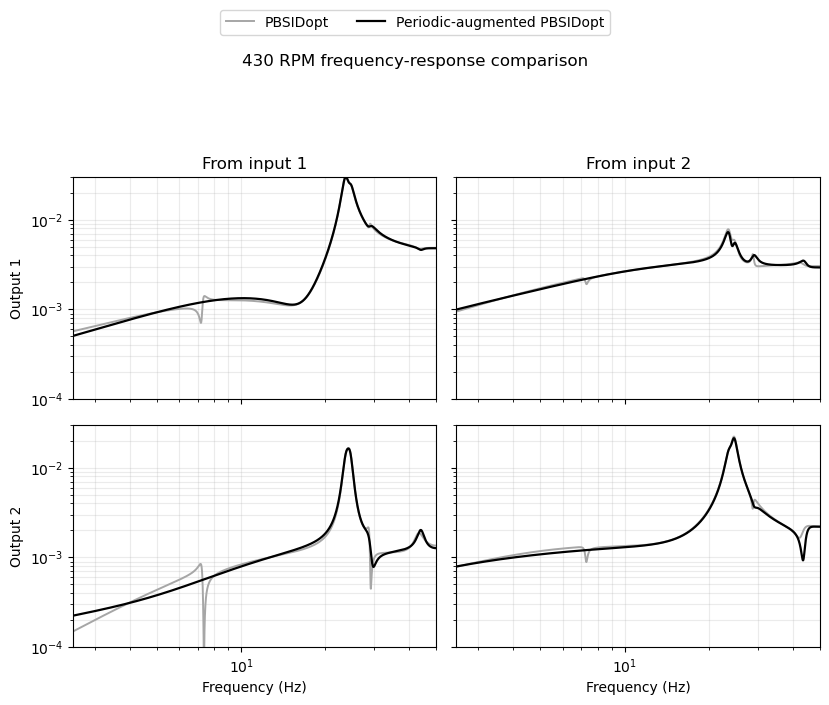

In [12]:
plain = case_430["response_plain"]
aug = case_430["response_aug"]
w = case_430["w"]
freq_hz = w / (2.0 * np.pi)
n_outputs, n_inputs, _ = plain.shape
fig, axes = plt.subplots(
    n_outputs,
    n_inputs,
    figsize=(4.2 * n_inputs, 3.4 * n_outputs),
    squeeze=False,
    sharex=True,
    sharey=True,
)
for row in range(n_outputs):
    for col in range(n_inputs):
        axis = axes[row, col]
        axis.loglog(freq_hz, plain[row, col, :], color="0.65", linewidth=1.4, label="PBSIDopt")
        axis.loglog(
            freq_hz,
            aug[row, col, :],
            color="k",
            linewidth=1.6,
            label="Periodic-augmented PBSIDopt",
        )
        axis.set_xlim(2.5, 50.0)
        axis.set_ylim(1e-4, 3e-2)
        axis.grid(True, which="both", alpha=0.25)
        if row == 0:
            axis.set_title(f"From input {col + 1}")
        if col == 0:
            axis.set_ylabel(f"Output {row + 1}")
        if row == n_outputs - 1:
            axis.set_xlabel("Frequency (Hz)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("430 RPM frequency-response comparison", y=0.965)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.88))